In [179]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence
from sklearn.inspection import permutation_importance
from scipy.stats import shapiro, jarque_bera, normaltest
from statsmodels.stats.stattools import durbin_watson

In [67]:
df = pd.read_csv('school_vacancies_cluster.csv')
df

,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,geo,salary,...,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,cluster
0,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,3100000000000,Уборщик производственных и служебных помещений,192624.0,Education,"Образование, наука","Белгородская область, Город Губкин, Мичурина у...",дом: ЗД. 21;,"{""latitude"": 51.28298, ""longitude"": 37.529349}",27100,...,0.057722,-0.081899,0.038661,0.053278,0.010140,0.068212,0.004134,0.162587,-0.010255,1
1,74fb9f78-f533-11f0-a027-0dd543315e5a,5200000000000,Помощник,177874.0,Industry,Производство,"Нижегородская область, Город Нижний Новгород, ...",дом: Д.5;,"{""latitude"": 56.250627, ""longitude"": 43.976396}",28000,...,0.433731,-1.244901,-0.453964,-0.078078,-0.887656,0.583995,-0.113060,0.443985,-0.465392,5
2,0bb2daf0-e166-11f0-a6fd-690b9f9d74c0,5200000000000,Гардеробщик,116334.0,Culture,"Искусство, культура и развлечения","Нижегородская область, Город Дзержинск, Ленина...",дом: 62;,"{""latitude"": 56.237197, ""longitude"": 43.456541}",27093,...,-0.460358,-0.148022,0.013027,0.095941,-0.017398,0.022478,-0.065008,0.011093,0.084217,2
3,4297f4e9-f68a-11f0-a027-0dd543315e5a,5200000000000,Уборщик производственных и служебных помещений,192588.0,Education,"Образование, наука","Нижегородская область, Город Выкса, Братьев Ба...",дом: ЗД. 3;,"{""latitude"": 55.320565, ""longitude"": 42.151576}",27903,...,-0.426072,-0.152778,-0.056101,0.098356,0.031274,0.019260,-0.067399,0.013763,0.059898,2
4,07e57c50-f6bc-11f0-8628-a3cca5294b78,6800000000000,Подсобный рабочий,167711.0,Industry,Производство,"Тамбовская область, Мордовский район, Промышле...",строение 1,"{""latitude"": 52.133137, ""longitude"": 40.824028}",28571,...,-0.085079,-0.038811,0.097795,0.077487,-0.047726,0.069215,0.005800,0.143342,0.007419,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,e02fe0b4-f76f-11f0-ba7d-9959eb3311ba,5200000000000,Подсобный рабочий,167711.0,Communal,"ЖКХ, эксплуатация","Нижегородская область, Город Выкса, Досчатое р...",дом ЗДАН 1,"{""latitude"": 55.378473, ""longitude"": 42.127672}",27093,...,1.608372,-1.591229,-0.249733,0.228790,-0.282225,0.095156,-0.005473,0.247849,-0.076026,0
2209,de298c18-0004-11f1-b4ed-438ed61bfb06,3800000000000,Подсобный рабочий,167711.0,ChemicalAndFuelIndustry,"Химическая, нефтехимическая, топливная промышл...","Иркутская область, Город Ангарск, Первый промы...",строение 5,"{""latitude"": 52.562356, ""longitude"": 103.88754}",30642,...,-0.482603,1.122433,-0.062016,-0.370358,-0.128499,-0.107353,-0.009474,-0.193175,0.222512,1
2210,fe989fbc-f2ab-11f0-8628-a3cca5294b78,3800000000000,Подсобный рабочий,167711.0,NotQualification,"Работы, не требующие квалификации","Иркутская область, Город Иркутск, Розы Люксемб...",дом: Д. 184;,"{""latitude"": 52.356439, ""longitude"": 104.15991}",8805,...,-0.415898,0.079133,-0.589814,-0.723773,0.024164,-0.176052,-0.123347,-0.240245,0.012623,2
2211,fe2217b8-f2cd-11f0-8628-a3cca5294b78,100000000000,Помощник,132479.0,DeskWork,"Административная работа, секретариат, АХО","Республика Адыгея (Адыгея), Тахтамукайский рай...",9/2 офис 1,"{""latitude"": 44.930838, ""longitude"": 38.927675}",27093,...,0.745092,0.527338,-0.750185,-0.063720,0.750351,-0.178098,-0.082453,-0.064384,-0.194891,2


**1. Выбор целевой переменной и признаков**

В качестве целевой переменной выбираем признак hourly_rate. Часовая ставка лучше отражает оплату труда в нашем случае, так как учитывает разный график работы. Для школьников выгоднее смотреть часовую ставку, так как часто предлагается сдельная оплата труда. 

Признаки для предсказания: 

exp_scaled	- опыт влияет на ставку, коррелирует с зарплатой

requirements_level	- уровень требований 

workPlaces - количество рабочих мест может влиять на ставку 

latitude - географический признак, коррелирует с зарплатой

longitude - географический признак, коррелирует с зарплатой

trainingDays – наличие дней для обучения может влиять на ставку

school_suitability_index - метрика вакансии подходящей для школьников

federal_district - региональный признак может влиять на ставку

JobRole_Полная занятость - тип занятости

JobRole_Временная - тип занятости

JobRole_Частичная занятость	- тип занятости

JobRole_Удалённая	- формат работы

In [68]:
# применяем One-hot encoding для федеральных округов
encoder = OneHotEncoder(sparse_output=False)
district_encoded = encoder.fit_transform(df[['federal_district']])
district_cols = [f"district_{cat}" for cat in encoder.categories_[0]]

district_df = pd.DataFrame(
    district_encoded,
    columns=district_cols,
    index=df.index
)

df = pd.concat([df, district_df], axis=1)

In [69]:
all_feat = [
    'exp_scaled',
    'requirements_level',
    'workPlaces',
    'latitude',
    'longitude',
    'trainingDays',
    'school_suitability_index',
    'premium_size',
    'JobRole_Полная занятость',
    'JobRole_Временная',
    'JobRole_Частичная занятость',
    'JobRole_Удалённая'
] + district_cols 

df_corr = df[all_feat].copy()
len(all_feat)

22

In [70]:
missing = df_corr.isna().sum()
print(missing[missing > 0] if any(missing > 0) else "Пропусков нет!")

if any(missing > 0):
    for feat in df_corr.columns:
        if df_corr[feat].isna().any():
            df_corr[feat] = df_corr[feat].fillna(df_corr[feat].median())
# заполняем пропуски медианой

latitude           7
longitude          7
premium_size    2095
dtype: int64


In [71]:
corr_matrix = df_corr.corr(method='spearman')

corr_matrix.round(3)

,exp_scaled,requirements_level,workPlaces,latitude,longitude,trainingDays,school_suitability_index,premium_size,JobRole_Полная занятость,JobRole_Временная,...,district_Дальневосточный,district_Другой,district_Неизвестно,district_Приволжский,district_Северо-Западный,district_Северо-Кавказский,district_Сибирский,district_Уральский,district_Центральный,district_Южный
exp_scaled,1.000,0.258,-0.045,0.047,0.011,-0.008,-0.121,-0.041,0.064,-0.064,...,-0.017,-0.003,0.139,0.042,0.018,-0.028,0.010,-0.005,-0.027,-0.032
requirements_level,0.258,1.000,-0.105,0.002,0.011,-0.019,-0.184,0.004,0.153,-0.205,...,-0.031,-0.015,0.044,0.109,0.040,-0.083,0.003,-0.065,-0.093,0.080
workPlaces,-0.045,-0.105,1.000,-0.222,-0.123,-0.008,0.300,-0.067,-0.285,0.333,...,0.057,0.038,-0.018,-0.175,-0.017,0.099,0.013,-0.056,0.165,-0.042
latitude,0.047,0.002,-0.222,1.000,0.026,0.020,-0.241,-0.037,0.247,-0.219,...,-0.096,-0.031,-0.002,0.300,0.194,-0.291,-0.177,0.319,0.002,-0.423
longitude,0.011,0.011,-0.123,0.026,1.000,0.024,-0.047,0.013,0.050,-0.032,...,0.187,-0.034,-0.029,0.146,-0.243,-0.019,0.678,0.226,-0.680,-0.237
trainingDays,-0.008,-0.019,-0.008,0.020,0.024,1.000,-0.005,0.000,-0.011,0.006,...,-0.006,-0.001,-0.001,-0.013,0.052,-0.009,0.016,0.057,-0.035,-0.015
school_suitability_index,-0.121,-0.184,0.300,-0.241,-0.047,-0.005,1.000,-0.021,-0.964,0.795,...,0.036,-0.017,-0.017,-0.229,0.012,0.093,0.060,0.059,0.043,0.090
premium_size,-0.041,0.004,-0.067,-0.037,0.013,0.000,-0.021,1.000,-0.029,0.023,...,0.000,0.000,0.000,-0.046,0.000,0.024,0.005,0.067,-0.053,0.087
JobRole_Полная занятость,0.064,0.153,-0.285,0.247,0.050,-0.011,-0.964,-0.029,1.000,-0.777,...,-0.032,0.017,0.017,0.227,-0.013,-0.086,-0.062,-0.053,-0.026,-0.126
JobRole_Временная,-0.064,-0.205,0.333,-0.219,-0.032,0.006,0.795,0.023,-0.777,1.000,...,0.053,-0.013,-0.013,-0.195,0.030,0.127,0.068,0.078,-0.009,0.051


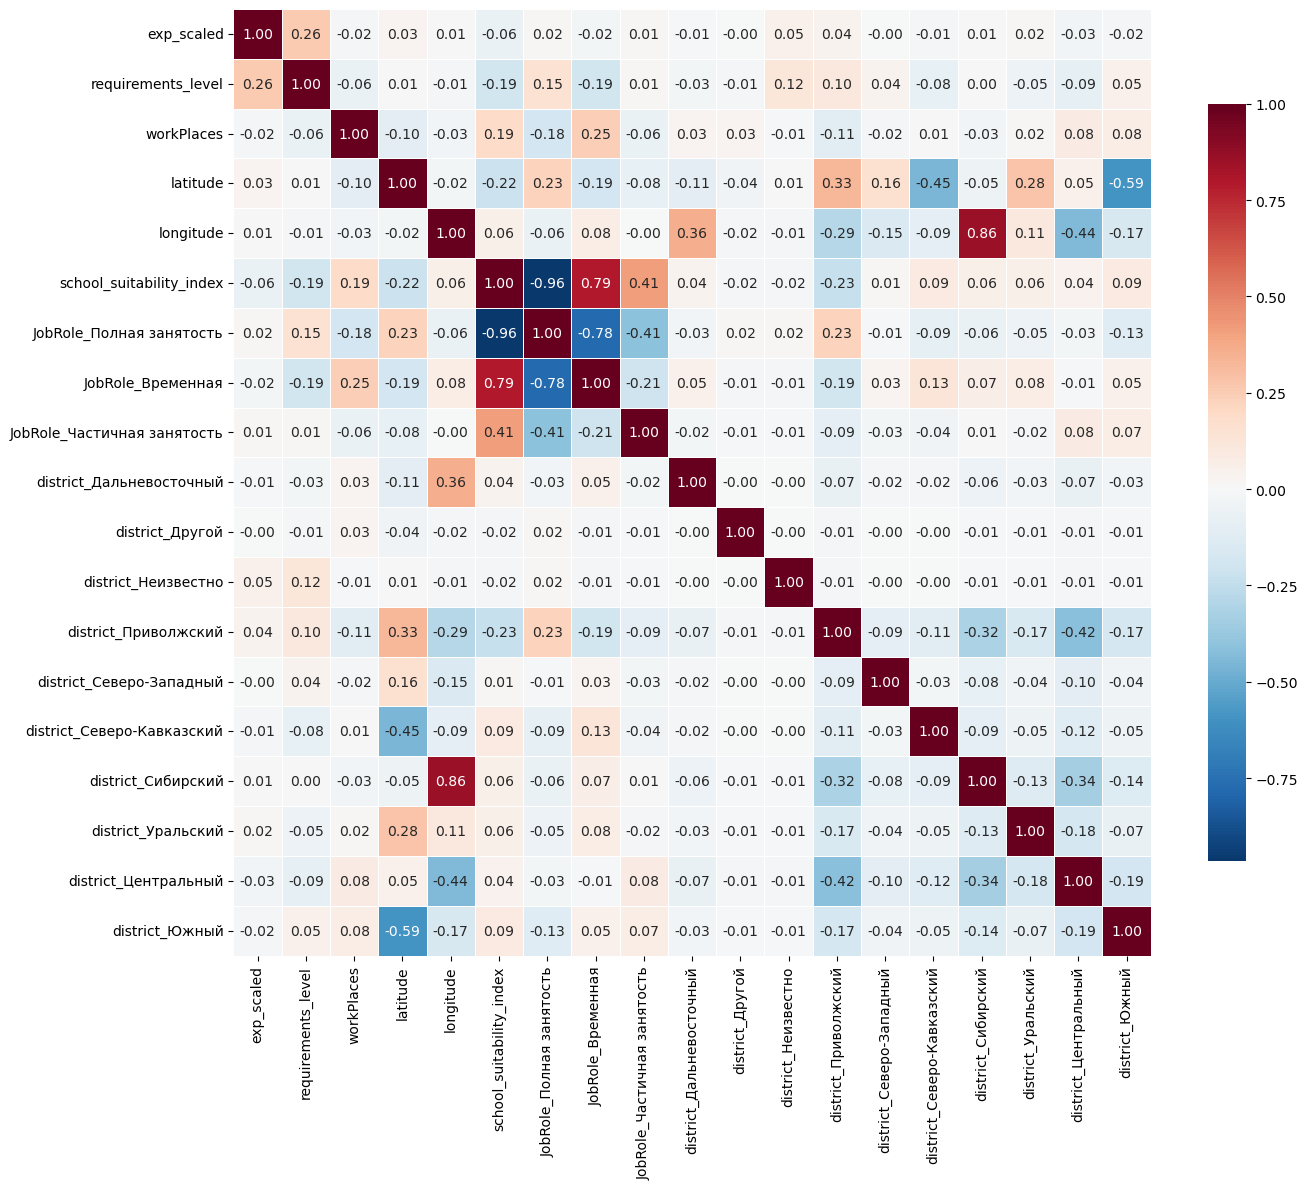

In [72]:
# Формируем матрицу признаков
X = df[all_feat].copy()
X = X.fillna(X.median())

core_feat = [
    'exp_scaled', 'requirements_level', 'workPlaces',
    'latitude', 'longitude', 'school_suitability_index',
    'JobRole_Полная занятость', 'JobRole_Временная', 'JobRole_Частичная занятость'
] + district_cols 

plt.figure(figsize=(14, 12))
corr = X[core_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.show()

Проблемные группы признаков с типами занятости у JobRole_Полная занятость, JobRole_Временная и school_suitability_index	из-за кодирования создают искусственные корреляции. longitude и округа Сибирский и Центральный создают географическую взаимосвязь. Все 8 округов между собой коррелируют из за кодирования. Применяем PCA для снижения размерности. 

In [93]:
loadings = pd.DataFrame(
    pca.components_[:n_components].T,  # срезаем первые n_components строк
    index=all_feat,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

loadings.head(25)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
exp_scaled,-0.049973,0.031516,-0.038076,-0.286061,0.230196,-0.356993,0.362335,-0.068612,-0.126870,-0.080441,-0.000157,0.003878,-0.162423,-0.489823,0.100039
requirements_level,-0.145135,0.031042,-0.183317,-0.328500,0.315608,-0.303136,0.241085,-0.038390,0.018634,0.013251,-0.015233,-0.001175,-0.137801,-0.020155,-0.034209
workPlaces,0.165412,-0.083531,0.040186,0.090383,-0.159600,-0.364860,-0.067894,-0.296354,-0.000948,-0.217762,0.068567,-0.054275,-0.142572,0.034837,-0.527548
latitude,-0.262088,0.077192,0.581903,-0.108252,0.078373,-0.063312,-0.107548,0.029597,0.031486,-0.013677,-0.024631,-0.002653,-0.061549,0.079630,0.082405
longitude,0.112862,0.646507,-0.029742,0.071947,0.034292,-0.004723,-0.019438,-0.038914,-0.065786,0.031880,-0.012135,0.010242,-0.022163,0.011723,0.001602
trainingDays,-0.014985,0.001608,-0.000025,-0.048879,-0.035981,0.046860,-0.131604,0.001594,-0.011738,-0.220520,-0.571713,0.733034,0.036439,-0.156285,-0.177387
school_suitability_index,0.512942,-0.069144,0.193249,-0.161734,0.079344,0.098249,0.045422,-0.042116,0.010989,0.000356,0.001934,0.011546,0.005176,0.025415,0.026907
premium_size,0.014381,0.001132,-0.055176,-0.086652,-0.141353,0.037097,0.295002,0.360732,-0.157273,0.030704,-0.082056,0.080856,-0.616934,0.519721,-0.165945
JobRole_Полная занятость,-0.510028,0.071786,-0.147279,0.204251,-0.115954,-0.059215,0.006861,0.025896,-0.016742,0.008349,0.024231,-0.015853,0.033074,-0.029448,-0.128324
JobRole_Временная,0.444255,-0.026240,0.178617,-0.130907,-0.283030,-0.207941,0.040782,-0.092433,0.109738,-0.084604,-0.073430,-0.054135,-0.025488,0.010045,0.178429


In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.9) + 1

n_components

np.int64(15)

более 90% дисперсии будет объяснять 15 признаков, на сонове которых создадим компоненты

In [74]:
pca_features = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.index
)

**2. Построение модели множественной линейной регрессии**

In [100]:
y = df['hourly_rate'].copy()

X = pca_features.copy()

valid_idx = y.notna() & (~X.isna().any(axis=1))
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1770, 15)
Размер тестовой выборки: (443, 15)


In [101]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [117]:
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"{'Метрика':<15} {'Train':>10} {'Test':>10}")
print(f"{'R квадрат':<15} {train_r2:>10.3f} {test_r2:>10.3f}")
print(f"{'RMSE':<15} {train_rmse:>10.2f} {test_rmse:>10.2f}")
print(f"{'MAE':<15} {train_mae:>10.2f} {test_mae:>10.2f}")

Метрика              Train       Test
R квадрат            0.792      0.514
RMSE                 36.84      51.37
MAE                  22.53      29.97


Модель объясняет около 40% вариации часовой ставки. Модель ошибается в среднем на 36 руб/час, примерно на 16% от типичной часовой ставки, это приемлемый результат. Метрики ошибки на тесте лучше, чем на тренировочном наборе, тестовая выборка проще для предсказания.

In [118]:
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lr.coef_
}).sort_values('Коэффициент', ascending=False)

print(coef_df.head(5).to_string(index=False))

print(coef_df.tail(5).to_string(index=False))

print(f"\nintercept: {lr.intercept_:.2f}")

Признак  Коэффициент
    PC5    27.419218
    PC6    16.272697
    PC1    15.300746
    PC2    12.580815
    PC9     5.874573
Признак  Коэффициент
   PC10     0.070836
    PC8    -2.125591
   PC15    -4.959070
   PC13    -5.038313
    PC4   -10.411440

intercept: 214.48


Свободный член 214.48 руб в час, это базовая часовая ставка при нулевых значениях всех главных компонент. 
Наибольший положительный вклад в часовую ставку вносят компоненты с квалификацией и типом занятости. Отрицательное влияние оказывает массовый найм и индекс подходимости для школьников.

In [119]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(lr, X, y, cv=kfold, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(lr, X, y, cv=kfold, 
                                    scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(lr, X, y, cv=kfold, 
                           scoring='neg_mean_absolute_error')

print(f"R квадрат: среднее = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"RMSE: среднее = {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"MAE: среднее = {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")

R квадрат: среднее = 0.314 ± 0.167
RMSE: среднее = 65.12 ± 7.22
MAE: среднее = 39.43 ± 2.71


Модель нестабильна, р квадрат варьируется. Ошибка держится на уровне 39-40 руб в час с небольшим разбросом. Модель чувствительна к составу обучающей выборки, имеет смысл применить более устойчивый Random Forest. 

In [120]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print(f"Количество деревьев: {rf.n_estimators}")
print(f"Максимальная глубина: {rf.max_depth}")

Количество деревьев: 100
Максимальная глубина: 10


In [121]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"{'Метрика':<15} {'Train':>10} {'Test':>10}")
print(f"{'R квадрат':<15} {train_r2:>10.3f} {test_r2:>10.3f}")
print(f"{'RMSE':<15} {train_rmse:>10.2f} {test_rmse:>10.2f}")
print(f"{'MAE':<15} {train_mae:>10.2f} {test_mae:>10.2f}")

Метрика              Train       Test
R квадрат            0.792      0.514
RMSE                 36.84      51.37
MAE                  22.53      29.97


Random Forest улучшил качество предсказаний, р квадрат вырос с 38.5% до 51.4%. Ошибка MAE снизилась. Но наблюдается переобучение, но тестовые метрики все равно лучше линейной модели. 

In [125]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(rf, X, y, cv=kfold, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(rf, X, y, cv=kfold, 
                                    scoring='neg_mean_squared_error'))
cv_mae = -cross_val_score(rf, X, y, cv=kfold, 
                           scoring='neg_mean_absolute_error')

print(f"R квадрат: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"MAE: {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"\nРазброс R квадрат: [{cv_r2.min():.3f}; {cv_r2.max():.3f}]")

R квадрат: 0.493 ± 0.056
RMSE: 56.33 ± 3.13
MAE: 32.77 ± 1.86

Разброс R квадрат: [0.433; 0.586]


Здесь более высокая стабильность на кросс-валидации, низкий разброс значений, значит модель устойчива к составу выборки. Модель достаточно надежна.

**3. Оценка значимости и важности признаков**

у Random Forest нет коэффициентов, вместо этого мы ссотрим на важность признаков и направление влияния через частичные зависимости

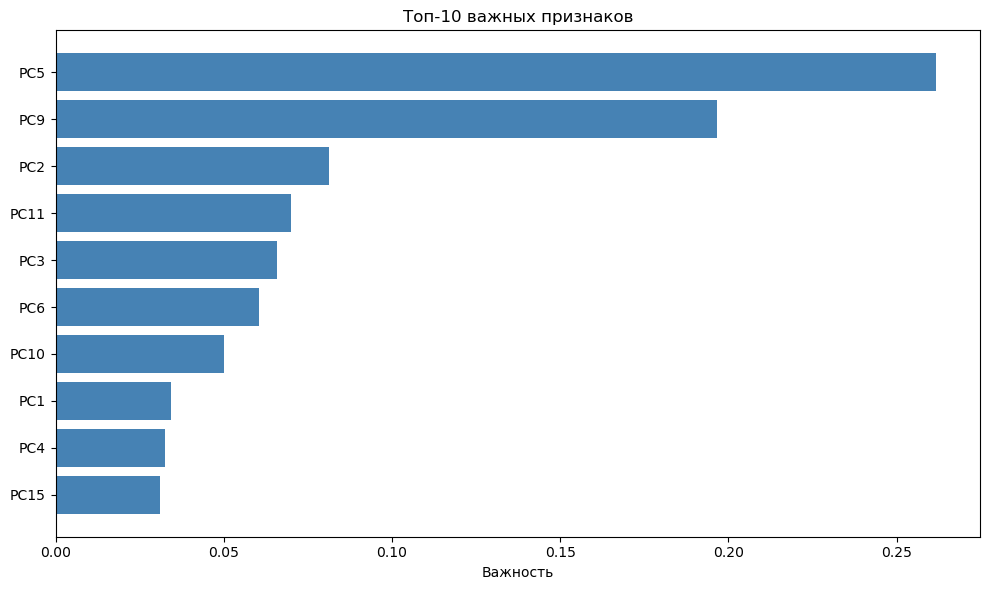

In [131]:
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf.feature_importances_
}).sort_values('Важность', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Признак'], 
         feature_importance.head(10)['Важность'],
         color='steelblue')
plt.xlabel('Важность')
plt.title('Топ-10 важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [156]:
results = []

for feature in X.columns: 
    pdp = partial_dependence(rf, X, [feature], grid_resolution=10)
    effects = pdp['average'][0]
    
    trend = np.polyfit(range(len(effects)), effects, 1)[0]
    direction = "положительное" if trend > 0 else "отрициательное"
    
    importance = feature_importance[feature_importance['Признак'] == feature]['Важность'].values[0]
    
    results.append({
        'Признак': feature,
        'Направление': direction,
        'Тренд': trend,
        'Эффект': effect,
        'Важность': importance
    })

pd.DataFrame(results)

,Признак,Направление,Тренд,Эффект,Важность
0,PC1,положительное,1.158152,-1.369704,0.034312
1,PC2,отрициательное,-1.929125,-1.369704,0.081258
2,PC3,положительное,0.608858,-1.369704,0.065674
3,PC4,отрициательное,-1.488001,-1.369704,0.032595
4,PC5,положительное,14.585632,-1.369704,0.261682
5,PC6,положительное,1.846861,-1.369704,0.060311
6,PC7,положительное,0.475334,-1.369704,0.021180
7,PC8,отрициательное,-0.448376,-1.369704,0.025116
8,PC9,положительное,6.231332,-1.369704,0.196597
9,PC10,отрициательное,-0.784328,-1.369704,0.050124


Наиболее сильное положительное влияние на часовую ставку оказывает PC5 - фактор наличия квалификации. Отрицательное влияние связано с PC2 - массовый найм и временная занятость. Остальные признаки влияют слабо или умеренно.

в Random Forest мы не можем оценить значимость через p-value, в место этого используем permutation importance, который показывает насколько ухудшится качество модели, если перемешать значения признака

In [161]:
perm_importance = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

significance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf.feature_importances_,
    'Permutation_mean': perm_importance.importances_mean,
    'Permutation_std': perm_importance.importances_std
}).sort_values('Permutation_mean', ascending=False)


significance_df

,Признак,Важность,Permutation_mean,Permutation_std
8,PC9,0.196597,0.318725,0.016226
4,PC5,0.261682,0.318199,0.038405
2,PC3,0.065674,0.058506,0.017719
10,PC11,0.069938,0.035665,0.020164
1,PC2,0.081258,0.032380,0.015250
3,PC4,0.032595,0.029739,0.006052
0,PC1,0.034312,0.019282,0.005420
13,PC14,0.028076,0.017297,0.006454
5,PC6,0.060311,0.015210,0.004914
9,PC10,0.050124,0.008674,0.007168


Модель имеет 9 статистически значимых признаков. Наибольший вклад вносят PC9 и PC5, если их удалеить R квадрат снизится более чем на 0.3. Они же и оказывают наибольшее влияние на переменную часовой ставки. Признаки PC7, PC8, PC12 показывают отрицательную важность, они незначимы в этой модели.

**4. Диагностика линейной модели**

In [162]:
y_pred = rf.predict(X_test)
residuals = y_test - y_pred

print(f"Среднее: {residuals.mean():.2f}")
print(f"Медиана: {np.median(residuals):.2f}")
print(f"Стандартное отклонение: {residuals.std():.2f}")
print(f"Мин: {residuals.min():.2f}")
print(f"Макс: {residuals.max():.2f}")

Среднее: -6.19
Медиана: -1.54
Стандартное отклонение: 51.05
Мин: -237.28
Макс: 195.07


Остатки модели имеют среднее близкое к нулю, но значительный разброс и наличие выбросов, присутсвует непостоянство дисперсии и возможно есть гетероскедастичность

In [172]:
y_pred_array = np.array(y_pred).reshape(-1, 1)
residuals_abs_array = np.array(residuals_abs)

lr = LinearRegression()
lr.fit(y_pred_array, residuals_abs_array)
trend = lr.coef_[0]

trend

np.float64(0.08006417779222369)

Да, есть умеренная гетероскедастичность, с ростом предсказанных значений разброс остатков будет увеличиваться

In [183]:
Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = residuals[(residuals < lower_bound) | (residuals > upper_bound)]

print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers)/len(residuals)*100:.2f}%")

Границы: [-45.61, 38.65]
Количество выбросов: 100
Доля выбросов: 22.57%


В остатках есть 100 выбросов, выходящих за границы, очень превышает допустимый уровень и тут действительно есть проблемы с качеством у модели линейной регрессии.

In [188]:
std_residuals = residuals / residuals.std()
influential = std_residuals[abs(std_residuals) > 3]

print(f"Наблюдений с остатком более 3: {len(influential)}")
print(f"Доля: {len(influential)/len(residuals)*100:.2f}%")

if len(influential) > 0:
    print(f"Максимальный студ. остаток: {std_residuals.abs().max():.2f}")

Наблюдений с остатком более 3: 14
Доля: 3.16%
Максимальный студ. остаток: 4.65


Модель содержит 14 наблюдений с остатками более трех стандартных отклонений, с экстремальным значением 4.65, присутсвуют влияющие выбросы.

In [189]:
dw = durbin_watson(residuals)
dw

np.float64(1.9852442766594416)

Автокорреляция остатков отсутствует.

**5. Общие выводы**

Модель Random Forest с умеренным качеством, объясняет половину вариации часовой ставки с небольшой ошибкой. Наиболее важными признаками являются признаки квалификации и региональных надбавок, которые в совокупности дают основной вклад в модель.
Модель стабильна на кросс-валидации и нет автокорреляции ошибок, но страдает от большого количества выбросов и умеренной гетероскедастичности.


Ожидаемые результаты: чем выше требования к опыту и образованию, тем выше оплата труда; восточные регионы платят больше; массовый найм снижает ставку; тип занятости влияет на ставку

Неожиданные результаты: р квадрат ожидался бОльшим, учитывая количество признаков; огромное количество выбросов в остатках; присутсвие гетероскедастичности; ожидалос что типы занятости будут самыми влияемыми; некоторые признаки ухудшают модель при включении

Чтобы улучшить модель можно почистить данные от выбросов, настроить гиперпараметры леса, уменьшив max_depth до 6 и увеличить min_samples_leaf до 15. Исключить PC7, PC8, PC12, оставить только 9 статистически значимых признаков. Применить логарифмирование часовой ставки для устранения гетероскедастичности.